<a href="https://colab.research.google.com/github/Anil2801/turbofan-rul-prediction/blob/main/turbofan_rul_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Turbofan Engine Remaining Useful Life (RUL) Prediction
**Dataset:** NASA C-MAPSS (FD001) | **Models:** Linear Regression baseline vs LSTM

Run the cells from top to bottom (Runtime > Run all also works).
Data citation: A. Saxena and K. Goebel (2008). *Turbofan Engine Degradation Simulation Data Set*, NASA Ames Prognostics Data Repository.

## 1. Setup

In [1]:
import os, glob, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# ---- settings you can experiment with ----
WINDOW  = 30    # past cycles the model sees
RUL_CAP = 125   # cap on RUL labels
SEED    = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


## 2. Download the data
This downloads the NASA dataset from the PHM Society mirror. If the download fails, download the dataset manually
(NASA Prognostics Data Repository or Kaggle: "NASA Turbofan Jet Engine Data Set"), then upload
`train_FD001.txt`, `test_FD001.txt` and `RUL_FD001.txt` using the folder icon on the left of Colab.

In [3]:
URL = "https://phm-datasets.s3.amazonaws.com/NASA/6.+Turbofan+Engine+Degradation+Simulation+Data+Set.zip"
!wget -q -O turbofan.zip "$URL"
!unzip -q -o turbofan.zip -d raw

# The archive may contain a nested zip, so extract those too
for z in glob.glob("raw/**/*.zip", recursive=True):
    with zipfile.ZipFile(z) as f:
        f.extractall(os.path.dirname(z))

found = glob.glob("raw/**/train_FD001.txt", recursive=True) or glob.glob("train_FD001.txt")
assert found, "train_FD001.txt not found. Upload the files manually (see note above)."
DATA_DIR = os.path.dirname(found[0]) or "."
print("Data folder:", DATA_DIR)
print(os.listdir(DATA_DIR))

Data folder: raw/6. Turbofan Engine Degradation Simulation Data Set
['train_FD004.txt', 'train_FD003.txt', 'test_FD001.txt', 'RUL_FD002.txt', 'train_FD002.txt', 'Damage Propagation Modeling.pdf', 'test_FD003.txt', 'RUL_FD001.txt', 'test_FD004.txt', 'readme.txt', 'test_FD002.txt', 'CMAPSSData.zip', 'RUL_FD004.txt', 'train_FD001.txt', 'RUL_FD003.txt']


## 3. Load and explore

In [4]:
cols = ["engine", "cycle", "op1", "op2", "op3"] + [f"s{i}" for i in range(1, 22)]

def load(name):
    return pd.read_csv(f"{DATA_DIR}/{name}", sep=r"\s+", header=None, names=cols)

train = load("train_FD001.txt")
test  = load("test_FD001.txt")
y_test = np.loadtxt(f"{DATA_DIR}/RUL_FD001.txt")   # true RUL at each test engine's last cycle

print("Train:", train.shape, "| engines:", train["engine"].nunique())
print("Test :", test.shape,  "| engines:", test["engine"].nunique())
train.head()

Train: (20631, 26) | engines: 100
Test : (13096, 26) | engines: 100


,engine,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


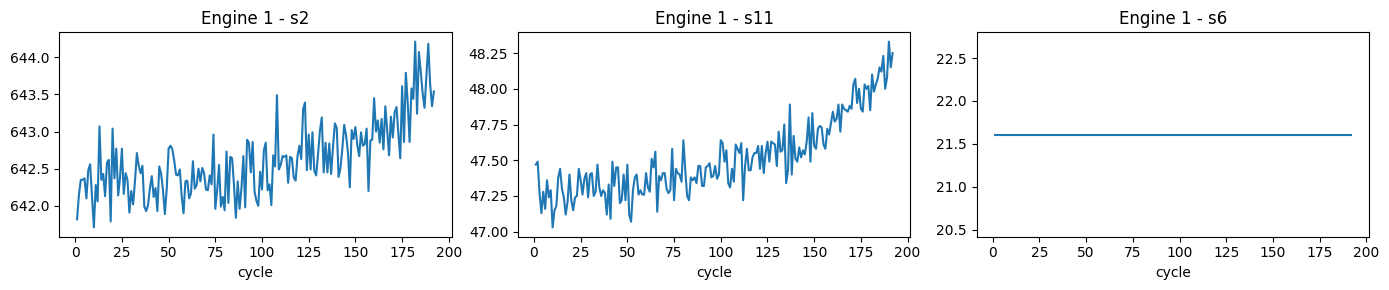

In [5]:
# How long do engines last? (training engines run until failure)
life = train.groupby("engine")["cycle"].max()
print(life.describe())

# Look at a few sensors for one engine: some trend clearly, some are flat
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
e1 = train[train["engine"] == 1]
for ax, s in zip(axes, ["s2", "s11", "s6"]):
    ax.plot(e1["cycle"], e1[s]); ax.set_title(f"Engine 1 - {s}"); ax.set_xlabel("cycle")
plt.tight_layout(); plt.show()

## 4. Prepare the data
- **RUL label** = last cycle of the engine - current cycle, capped at `RUL_CAP`
- Drop sensors that are constant in FD001
- Scale features using **training data only**

In [6]:
train["RUL"] = train.groupby("engine")["cycle"].transform("max") - train["cycle"]
train["RUL"] = train["RUL"].clip(upper=RUL_CAP)

drop_cols = ["op3", "s1", "s5", "s6", "s10", "s16", "s18", "s19"]
features = [c for c in cols[2:] if c not in drop_cols]
print(len(features), "features:", features)

scaler = MinMaxScaler()
train[features] = scaler.fit_transform(train[features])   # fit on train only
test[features]  = scaler.transform(test[features])

16 features: ['op1', 'op2', 's2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']


## 5. Build sliding windows

In [7]:
def make_train_windows(df):
    X, y, eng = [], [], []
    for e, g in df.groupby("engine"):
        arr, rul = g[features].values, g["RUL"].values
        for i in range(WINDOW, len(g) + 1):
            X.append(arr[i - WINDOW:i]); y.append(rul[i - 1]); eng.append(e)
    return np.array(X), np.array(y), np.array(eng)

def make_test_windows(df):
    X = []
    for e, g in df.groupby("engine"):
        arr = g[features].values[-WINDOW:]
        if len(arr) < WINDOW:   # pad short engines by repeating the first row
            arr = np.vstack([np.repeat(arr[:1], WINDOW - len(arr), axis=0), arr])
        X.append(arr)
    return np.array(X)

X_all, y_all, eng_all = make_train_windows(train)
X_test = make_test_windows(test)
print("Train windows:", X_all.shape, "| Test windows:", X_test.shape)

# Validation split BY ENGINE (windows from one engine are highly correlated)
rng = np.random.default_rng(SEED)
val_engines = rng.choice(train["engine"].unique(), size=15, replace=False)
val_mask = np.isin(eng_all, val_engines)
X_tr, y_tr   = X_all[~val_mask], y_all[~val_mask]
X_val, y_val = X_all[val_mask],  y_all[val_mask]
print("Train:", X_tr.shape, "| Val:", X_val.shape)

Train windows: (17731, 30, 16) | Test windows: (100, 30, 16)
Train: (15170, 30, 16) | Val: (2561, 30, 16)


## 6. Metrics and baseline

In [8]:
def rmse(a, b):
    return float(np.sqrt(mean_squared_error(a, b)))

def nasa_score(true, pred):
    # Asymmetric PHM08 score: late predictions are penalized more. Lower is better.
    d = pred - true
    return float(np.sum(np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)))

lin = LinearRegression().fit(X_tr.reshape(len(X_tr), -1), y_tr)
pred_lin = np.clip(lin.predict(X_test.reshape(len(X_test), -1)), 0, None)
rmse_lin = rmse(y_test, pred_lin)
print(f"Linear Regression | RMSE: {rmse_lin:.2f} | NASA score: {nasa_score(y_test, pred_lin):.0f}")

Linear Regression | RMSE: 16.31 | NASA score: 413


## 7. Train the LSTM

In [9]:
model = models.Sequential([
    layers.Input(shape=(WINDOW, len(features))),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32),
    layers.Dropout(0.2),
    layers.Dense(32, activation="relu"),
    layers.Dense(1),
])
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")
model.summary()

early_stop = callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
history = model.fit(X_tr, y_tr, validation_data=(X_val, y_val),
                    epochs=60, batch_size=128, callbacks=[early_stop], verbose=2)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        20,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,241 (133.75 KB)

 Trainable params: 34,241 (133.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
119/119 - 14s - 115ms/step - loss: 6093.3950 - val_loss: 3688.4546
Epoch 2/60
119/119 - 9s - 75ms/step - loss: 2565.3826 - val_loss: 1794.9678
Epoch 3/60
119/119 - 10s - 82ms/step - loss: 1810.1113 - val_loss: 1744.4662
Epoch 4/60
119/119 - 7s - 59ms/step - loss: 1800.2241 - val_loss: 1744.9338
Epoch 5/60
119/119 - 9s - 72ms/step - loss: 1795.6156 - val_loss: 1744.6948
Epoch 6/60
119/119 - 7s - 60ms/step - loss: 1796.7466 - val_loss: 1735.7913
Epoch 7/60
119/119 - 9s - 73ms/step - loss: 1547.5886 - val_loss: 874.1819
Epoch 8/60
119/119 - 9s - 75ms/step - loss: 707.4419 - val_loss: 477.6958
Epoch 9/60
119/119 - 7s - 59ms/step - loss: 407.4630 - val_loss: 275.8061
Epoch 10/60
119/119 - 11s - 95ms/step - loss: 300.1909 - val_loss: 259.0217
Epoch 11/60
119/119 - 11s - 91ms/step - loss: 266.3374 - val_loss: 241.6791
Epoch 12/60
119/119 - 7s - 60ms/step - loss: 257.8741 - val_loss: 227.3331
Epoch 13/60
119/119 - 10s - 85ms/step - loss: 245.8960 - val_loss: 237.4900
Epoch 14/60
119

## 8. Evaluate and compare

In [10]:
pred_lstm = np.clip(model.predict(X_test).ravel(), 0, None)
rmse_lstm = rmse(y_test, pred_lstm)
improvement = (rmse_lin - rmse_lstm) / rmse_lin * 100

print(f"Baseline RMSE : {rmse_lin:.2f} cycles   | NASA score: {nasa_score(y_test, pred_lin):.0f}")
print(f"LSTM RMSE     : {rmse_lstm:.2f} cycles   | NASA score: {nasa_score(y_test, pred_lstm):.0f}")
print(f"Improvement   : {improvement:.1f}%")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step
===== RESULTS FOR YOUR RESUME =====
Baseline RMSE : 16.31 cycles   | NASA score: 413
LSTM RMSE     : 15.18 cycles   | NASA score: 396
Improvement   : 6.9%


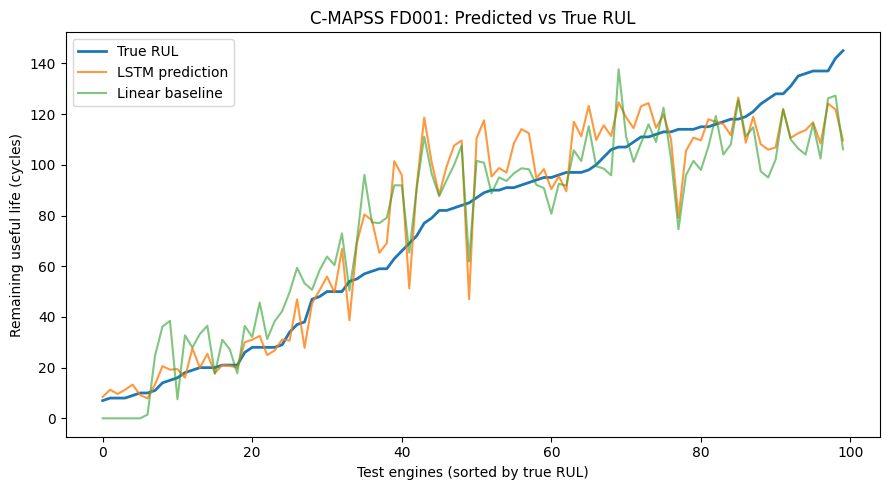

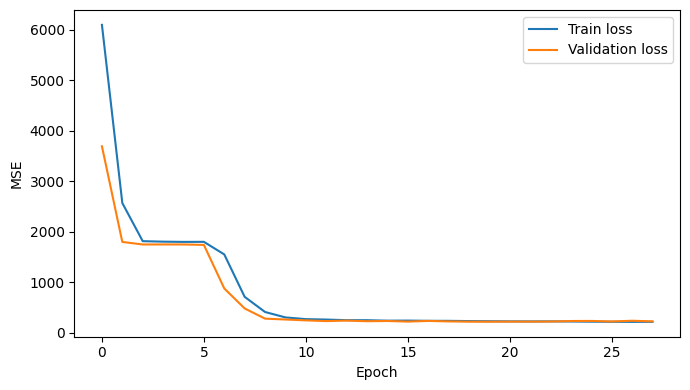

In [11]:
order = np.argsort(y_test)
plt.figure(figsize=(9, 5))
plt.plot(y_test[order], label="True RUL", linewidth=2)
plt.plot(pred_lstm[order], label="LSTM prediction", alpha=0.8)
plt.plot(pred_lin[order], label="Linear baseline", alpha=0.6)
plt.xlabel("Test engines (sorted by true RUL)"); plt.ylabel("Remaining useful life (cycles)")
plt.title("C-MAPSS FD001: Predicted vs True RUL"); plt.legend(); plt.tight_layout()
plt.savefig("rul_predictions.png", dpi=150); plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.legend(); plt.tight_layout()
plt.savefig("training_curve.png", dpi=150); plt.show()

## 9. Save your work
Downloads the plots to your computer for your GitHub README.
Also use **File > Save a copy in GitHub** (or download as .ipynb) to publish the notebook.

In [13]:
from google.colab import files
files.download("rul_predictions.png")
files.download("training_curve.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 10. Experiments (for your README and interviews)
Change a setting at the top (`WINDOW` or `RUL_CAP`), then **Runtime > Restart and run all**.
Record each result here:

| Experiment | WINDOW | RUL_CAP | Baseline RMSE | LSTM RMSE |
|---|---|---|---|---|
| Default | 30 | 125 | | |
| Longer window | 50 | 125 | | |
| Lower cap | 30 | 100 | | |